In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create Synthetic Dataset (50 samples, 2 features)
# -------------------------------------------------

torch.manual_seed(42)

X = torch.randn(50, 2)

true_w = torch.tensor([[2.0], [-3.0]])
true_b = 1.0

y = torch.sigmoid(X @ true_w + true_b)
y = (y > 0.5).float()   # Convert to binary 0/1

dataset = TensorDataset(X, y)


In [3]:
X.shape

torch.Size([50, 2])

In [4]:
# -------------------------------------------------
# Define Simple Model
# -------------------------------------------------

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


In [5]:
# -------------------------------------------------
#  Training Function
# -------------------------------------------------

def train_model(batch_size, epochs):

    model = SimpleModel()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []
    total_updates = 0

    for epoch in range(epochs):
        epoch_loss = 0

        for xb, yb in loader:
            preds = model(xb)
            loss = criterion(preds, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            total_updates += 1

        losses.append(epoch_loss / len(loader))

    print(f"Batch Size: {batch_size}")
    print(f"Total Weight Updates: {total_updates}")
    print("-" * 40)

    return losses


In [6]:
# -------------------------------------------------
#  Train with SGD (batch_size = 1)
# -------------------------------------------------

loss_sgd = train_model(batch_size=1, epochs=5)

Batch Size: 1
Total Weight Updates: 250
----------------------------------------


In [7]:
# -------------------------------------------------
#  Train with Batch Gradient Descent (batch_size = 50)
# -------------------------------------------------

loss_batch = train_model(batch_size=50, epochs=5)


Batch Size: 50
Total Weight Updates: 5
----------------------------------------


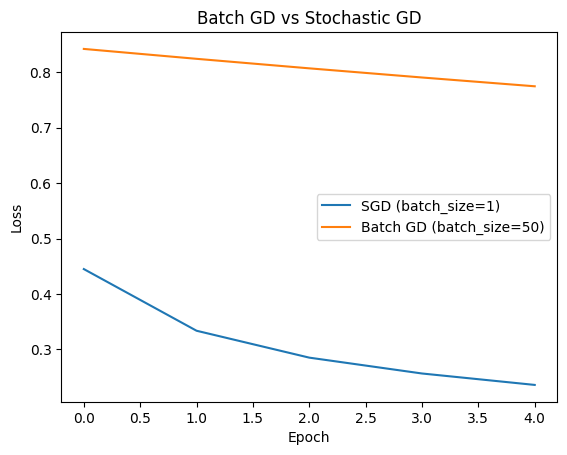

In [8]:
# -------------------------------------------------
# Plot Comparison
# -------------------------------------------------

plt.plot(loss_sgd, label="SGD (batch_size=1)")
plt.plot(loss_batch, label="Batch GD (batch_size=50)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Batch GD vs Stochastic GD")
plt.show()

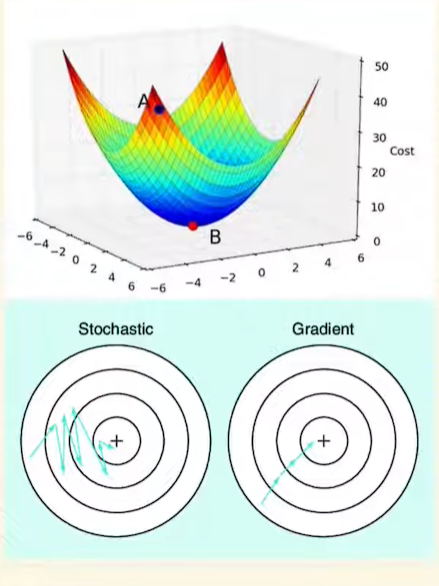

# SGD converges faster in terms of epochs because it makes many updates per epoch.

# Batch GD is smoother but much slower when epochs are small.